In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve 
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier


In [2]:
df = pd.read_csv('train.csv')
df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Survived', 'Parch', 'SibSp']]
df.dropna(inplace=True)

#convert sex to numbers 0-1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(df.shape)
print(df.isnull().sum())
df.head(10)

(714, 7)
Pclass      0
Sex         0
Age         0
Fare        0
Survived    0
Parch       0
SibSp       0
dtype: int64


,Pclass,Sex,Age,Fare,Survived,Parch,SibSp
0,3,0,22.0,7.2500,0,0,1
1,1,1,38.0,71.2833,1,0,1
2,3,1,26.0,7.9250,1,0,0
3,1,1,35.0,53.1000,1,0,1
4,3,0,35.0,8.0500,0,0,0
6,1,0,54.0,51.8625,0,0,0
7,3,0,2.0,21.0750,0,1,3
8,3,1,27.0,11.1333,1,2,0
9,2,1,14.0,30.0708,1,0,1
10,3,1,4.0,16.7000,1,1,1


XGBoost | train accuracy: 0.8879 | test accuracy: 0.8042
XGBoost | train AUC: 0.9473 | test AUC: 0.8349
Pclass: 0.1861
Sex: 0.6328
Age: 0.0540
Fare: 0.0403
Parch: 0.0177
SibSp: 0.0691


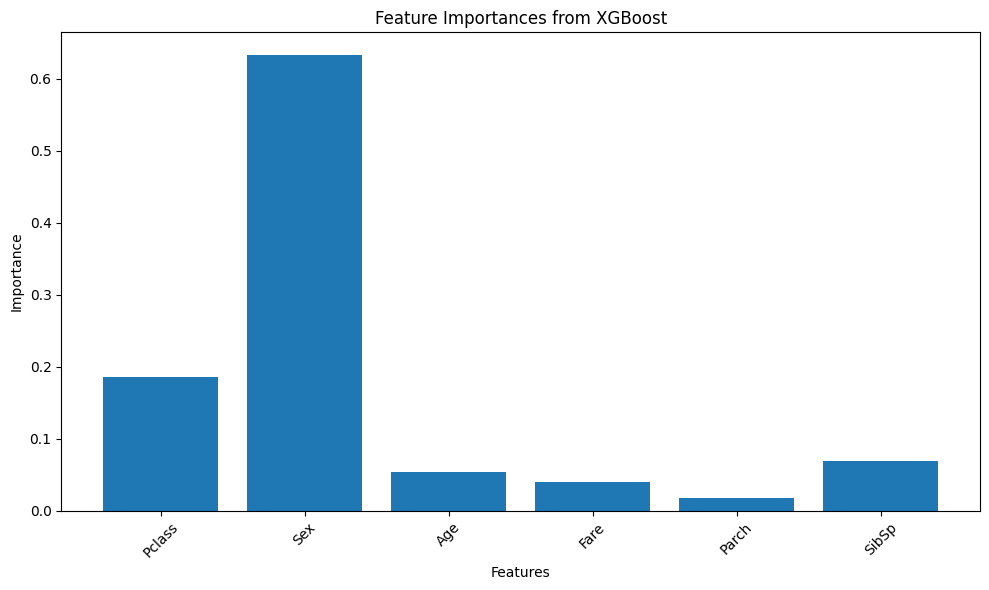

In [5]:
x =df.drop(columns='Survived')
y = df['Survived']

#train split test 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)    

model_xgb.fit(x_train, y_train, 
              eval_set=[(x_test, y_test)],
              verbose=False)

print(f"XGBoost | train accuracy: {accuracy_score(y_train, model_xgb.predict(x_train)):.4f} | test accuracy: {accuracy_score(y_test, model_xgb.predict(x_test)):.4f}")



train_auc = roc_auc_score(y_train, model_xgb.predict_proba(x_train)[:, 1])
test_auc = roc_auc_score(y_test, model_xgb.predict_proba(x_test)[:, 1])
print(f"XGBoost | train AUC: {train_auc:.4f} | test AUC: {test_auc:.4f}")

importances = model_xgb.feature_importances_
feature_names = x.columns 
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")

plt.figure(figsize=(10, 6))
plt.bar(feature_names, importances)
plt.title('Feature Importances from XGBoost')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

